In [1]:
import pydicom

# Load the DICOM file
ds = pydicom.dcmread("data/1.2.826.0.1.3680043.10.1561.777.2022.100/1.2.826.0.1.3680043.10.1561.777.2022.100.3.1430660.147-RTDOSE.dcm")

# Basic info
print(ds)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 190
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: RT Dose Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.10.1561.777.2022.100.3.1430660.147
(0002, 0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.246.352.70.2.1.160.3
(0002, 0013) Implementation Version Name         SH: 'DCIE 17.0'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 192'
(0008, 0012) Instance Creation Date              DA: '20250920'
(0008, 0013) Instance Creation Time              TM: '150903'
(0008, 0016) SOP Class UID                       UI: RT Dose Storage
(0008, 0018) SOP Instance UID                    UI: 1.2.826.0.1.3680043.10.1561.777.2022.100.3.1430660.147
(0008, 002

In [18]:
import pydicom

ds = pydicom.dcmread("data/1.2.826.0.1.3680043.10.1561.777.2022.100/1.2.826.0.1.3680043.10.1561.777.2022.100.3.1430660.147-RTDOSE.dcm")


print("Has Pixel Data:", 'PixelData' in ds)
print("Number of frames:", ds.NumberOfFrames)

Has Pixel Data: True
Number of frames: 195


In [19]:
import numpy as np

# Get raw pixel array
dose_grid = ds.pixel_array
print(dose_grid)

print("Dose grid shape:", dose_grid.shape)
print("Dose grid Scaling:", ds.DoseGridScaling)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
Dose grid shape: (195, 98, 221)
Dose grid Scaling: 1.7411744221e-05


In [5]:
dose_grid_scaled = dose_grid * ds.DoseGridScaling

print("Max dose:", np.max(dose_grid_scaled))

Max dose: 41.61850868296636


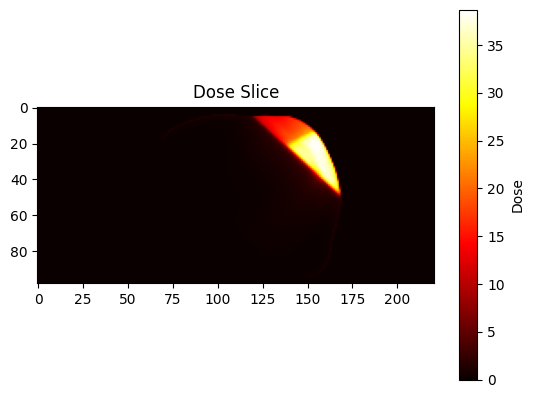

In [26]:
import matplotlib.pyplot as plt

# Show middle slice
slice_index = dose_grid_scaled.shape[0] // 2

plt.imshow(dose_grid_scaled[50, :, :], cmap="hot")
plt.colorbar(label="Dose")
plt.title("Dose Slice")
plt.show()

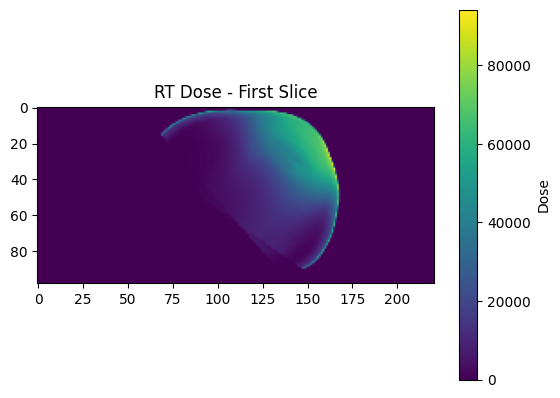

In [27]:
import matplotlib.pyplot as plt

dose_grid = ds.pixel_array


first_slice = dose_grid[35, :, :]  # first axial slice

plt.imshow(first_slice)
plt.colorbar(label="Dose")
plt.title("RT Dose - First Slice")
plt.show()

In [33]:
from pathlib import Path
import pydicom
import pandas as pd


def read_rtplan_to_dataframe(root_dir):
    """
    Read RTPLAN DICOM files recursively and return
    a pandas DataFrame with beam/control-point data.
    """

    rows = []

    root_path = Path(root_dir)

    for file_path in root_path.rglob("*"):

        if not file_path.is_file():
            continue

        try:
            ds = pydicom.dcmread(
                file_path,
                stop_before_pixels=True,
                force=True
            )

            # Keep only RTPLAN modality
            if getattr(ds, "Modality", "") != "RTPLAN":
                continue

            # -------------------------------------------------
            # Administrative metadata
            # -------------------------------------------------
            patient_name = str(getattr(ds, "PatientName", ""))
            patient_id = getattr(ds, "PatientID", "")
            birth_date = getattr(ds, "PatientBirthDate", "")
            sop_instance_uid = getattr(ds, "SOPInstanceUID", "")

            # Referenced RS UID
            referenced_rs_uid = None

            if hasattr(ds, "ReferencedStructureSetSequence"):
                try:
                    referenced_rs_uid = (
                        ds.ReferencedStructureSetSequence[0]
                        .ReferencedSOPInstanceUID
                    )
                except Exception:
                    pass

            # -------------------------------------------------
            # Fraction info
            # -------------------------------------------------
            number_of_fractions_planned = None
            number_of_beams = None

            if hasattr(ds, "FractionGroupSequence"):
                fg = ds.FractionGroupSequence[0]

                number_of_fractions_planned = getattr(
                    fg,
                    "NumberOfFractionsPlanned",
                    None
                )

                number_of_beams = getattr(
                    fg,
                    "NumberOfBeams",
                    None
                )

            # -------------------------------------------------
            # Dose Reference
            # -------------------------------------------------
            target_prescription_dose = None

            if hasattr(ds, "DoseReferenceSequence"):
                try:
                    target_prescription_dose = getattr(
                        ds.DoseReferenceSequence[0],
                        "TargetPrescriptionDose",
                        None
                    )
                except Exception:
                    pass

            # -------------------------------------------------
            # Beam Sequence
            # -------------------------------------------------
            if hasattr(ds, "BeamSequence"):

                for beam in ds.BeamSequence:

                    beam_number = getattr(
                        beam,
                        "BeamNumber",
                        None
                    )

                    beam_name = getattr(
                        beam,
                        "BeamName",
                        None
                    )

                    beam_type = getattr(
                        beam,
                        "BeamType",
                        None
                    )

                    radiation_type = getattr(
                        beam,
                        "RadiationType",
                        None
                    )

                    machine_name = getattr(
                        beam,
                        "TreatmentMachineName",
                        None
                    )

                    final_meterset = getattr(
                        beam,
                        "FinalCumulativeMetersetWeight",
                        None
                    )

                    number_of_control_points = getattr(
                        beam,
                        "NumberOfControlPoints",
                        None
                    )

                    # -----------------------------------------
                    # Control Point Sequence
                    # -----------------------------------------
                    if hasattr(beam, "ControlPointSequence"):

                        for cp in beam.ControlPointSequence:

                            control_point_index = getattr(
                                cp,
                                "ControlPointIndex",
                                None
                            )

                            gantry_angle = getattr(
                                cp,
                                "GantryAngle",
                                None
                            )

                            collimator_angle = getattr(
                                cp,
                                "BeamLimitingDeviceAngle",
                                None
                            )

                            couch_angle = getattr(
                                cp,
                                "PatientSupportAngle",
                                None
                            )

                            cumulative_meterset_weight = getattr(
                                cp,
                                "CumulativeMetersetWeight",
                                None
                            )

                            isocenter_position = getattr(
                                cp,
                                "IsocenterPosition",
                                None
                            )

                            # ---------------------------------
                            # MLC / Jaw positions
                            # ---------------------------------
                            mlc_positions = []

                            if hasattr(
                                cp,
                                "BeamLimitingDevicePositionSequence"
                            ):

                                for bld in (
                                    cp.BeamLimitingDevicePositionSequence
                                ):

                                    device_type = getattr(
                                        bld,
                                        "RTBeamLimitingDeviceType",
                                        None
                                    )

                                    leaf_positions = getattr(
                                        bld,
                                        "LeafJawPositions",
                                        None
                                    )

                                    mlc_positions.append({
                                        "device_type": device_type,
                                        "positions": leaf_positions
                                    })

                            # ---------------------------------
                            # Create row
                            # ---------------------------------
                            row = {
                                "file_path": str(file_path),

                                # Patient
                                "patient_name": patient_name,
                                "patient_id": patient_id,
                                "birth_date": birth_date,

                                # UIDs
                                "sop_instance_uid": sop_instance_uid,
                                "referenced_rs_uid": referenced_rs_uid,

                                # Prescription
                                "fractions_planned":
                                    number_of_fractions_planned,

                                "target_prescription_dose":
                                    target_prescription_dose,

                                "number_of_beams":
                                    number_of_beams,

                                # Beam
                                "beam_number": beam_number,
                                "beam_name": beam_name,
                                "beam_type": beam_type,
                                "radiation_type": radiation_type,
                                "machine_name": machine_name,
                                "final_meterset": final_meterset,
                                "number_of_control_points":
                                    number_of_control_points,

                                # Control Point
                                "control_point_index":
                                    control_point_index,

                                "gantry_angle": gantry_angle,
                                "collimator_angle":
                                    collimator_angle,

                                "couch_angle": couch_angle,

                                "cumulative_meterset_weight":
                                    cumulative_meterset_weight,

                                "isocenter_position":
                                    isocenter_position,

                                # MLC
                                "mlc_positions":
                                    mlc_positions
                            }

                            rows.append(row)

        except Exception as e:
            print(f"Skipping {file_path}: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(rows)

    return df

In [42]:
df = read_rtplan_to_dataframe(r"data/Prostate prime d11 CT RT RP and RD")

In [39]:
df = df.drop_duplicates(subset=["sop_instance_uid"])
# df.to_csv("data.csv")

In [43]:
df.to_csv("data.csv", index=False)

In [ ]:
# predicted

import SimpleITK as sitk
import numpy as np

img = sitk.ReadImage("/mnt/nvme/nvme-2TB-storage/sougata/python/Multichannel-Dose-Prediction-for-Radiotherapy-Planning/data/output/test5/prostate_000_predicted_dose.nii.gz")
data = sitk.GetArrayFromImage(img)  # numpy array — axes are (Z, Y, X)

print(data.shape)
print(img.GetSpacing())    # (x, y, z) in mm
print(img.GetOrigin())
print(img.GetDirection())

(240, 512, 512)
(1.269531011581421, 1.269531011581421, 2.5)
(-337.70001220703125, -325.0, -278.5)
(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


In [2]:
# actual 

import SimpleITK as sitk
import numpy as np

img = sitk.ReadImage("/mnt/nvme/nvme-2TB-storage/sougata/python/Multichannel-Dose-Prediction-for-Radiotherapy-Planning/nnUNet_raw/Dataset001_ProstateDose/labelsTr/prostate_000.nii.gz")
data = sitk.GetArrayFromImage(img)  # numpy array — axes are (Z, Y, X)

print(data.shape)
print(img.GetSpacing())    # (x, y, z) in mm
print(img.GetOrigin())
print(img.GetDirection())

(240, 512, 512)
(1.269531011581421, 1.269531011581421, 2.5)
(-337.70001220703125, -325.0, -278.5)
(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


In [ ]:
import pydicom
import SimpleITK as sitk
import numpy as np
import copy

# ── Paths ────────────────────────────────────────────────────────────────────
RTDOSE_PATH = "/mnt/nvme/nvme-2TB-storage/sougata/python/Multichannel-Dose-Prediction-for-Radiotherapy-Planning/data/Prostate PRIME Standard arm d69/1de3b35a.8614.43b1.8bb4.37877ce504dd/1.2.826.0.1.3680043.10.1561.612.8957.399/1.2.826.0.1.3680043.10.1561.612.8957.399.3.5719013.680-RTDOSE.dcm"
NIFTI_PATH  = "/mnt/nvme/nvme-2TB-storage/sougata/python/Multichannel-Dose-Prediction-for-Radiotherapy-Planning/data/output/test5/prostate_000_predicted_dose.nii.gz"
OUT_PATH    = "/mnt/nvme/nvme-2TB-storage/sougata/python/Multichannel-Dose-Prediction-for-Radiotherapy-Planning/data/output/prostate_000_predicted_dose_RTDOSE.dcm"

# ── 1. Load reference DICOM — ALL metadata is preserved as-is ────────────────
ds = pydicom.dcmread(RTDOSE_PATH)
print(f"Reference DICOM grid: {ds.NumberOfFrames} frames x {ds.Rows} rows x {ds.Columns} cols")
print(f"  Spacing XY: {ds.PixelSpacing}, Origin: {[float(v) for v in ds.ImagePositionPatient]}")

# ── 2. Build SimpleITK reference image from the DICOM grid geometry ──────────
origin    = [float(v) for v in ds.ImagePositionPatient]
spacing_xy = [float(v) for v in ds.PixelSpacing]           # [row_spacing, col_spacing]
offsets   = [float(v) for v in ds.GridFrameOffsetVector]
spacing_z = offsets[1] - offsets[0]                        # uniform Z spacing

iop = [float(v) for v in ds.ImageOrientationPatient]
row_cos = np.array(iop[0:3])
col_cos = np.array(iop[3:6])
nor_cos = np.cross(row_cos, col_cos)
direction = tuple(row_cos.tolist() + col_cos.tolist() + nor_cos.tolist())

# sitk size = (X=cols, Y=rows, Z=frames), spacing = (x, y, z)
ref_size    = (int(ds.Columns), int(ds.Rows), int(ds.NumberOfFrames))
ref_spacing = (spacing_xy[1], spacing_xy[0], spacing_z)

ref_img = sitk.Image(ref_size, sitk.sitkFloat32)
ref_img.SetSpacing(ref_spacing)
ref_img.SetOrigin(origin)
ref_img.SetDirection(direction)

# ── 3. Load predicted NIfTI and resample onto DICOM grid ─────────────────────
pred_sitk = sitk.ReadImage(NIFTI_PATH)
print(f"NIfTI size={pred_sitk.GetSize()}, spacing={pred_sitk.GetSpacing()}")

resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(ref_img)
resampler.SetInterpolator(sitk.sitkLinear)
resampler.SetDefaultPixelValue(0.0)
pred_on_dicom_grid = resampler.Execute(pred_sitk)

# sitk.GetArrayFromImage → (Z, Y, X) = (frames, rows, cols) — exact match to DICOM pixel_array
pred_gy = sitk.GetArrayFromImage(pred_on_dicom_grid).astype(np.float32)
pred_gy = np.clip(pred_gy, 0.0, None)
print(f"Resampled shape: {pred_gy.shape}  (frames, rows, cols)")
print(f"Dose range: [{pred_gy.min():.2f}, {pred_gy.max():.2f}] Gy")

# ── 4. Gy → uint32 with a new DoseGridScaling ────────────────────────────────
max_dose = float(pred_gy.max())
new_scaling = max_dose / (2**32 - 1) if max_dose > 0 else 1e-5
pixels = np.round(pred_gy / new_scaling).astype(np.uint32)

# ── 5. Replace ONLY pixel data and scaling — keep every other DICOM tag ──────
ds.PixelData           = pixels.tobytes()
ds.DoseGridScaling     = f"{new_scaling:.10e}"
# Grid geometry stays identical to reference (same Rows/Cols/Frames/Spacing/Origin)
# All patient, study, plan, structure UIDs and sequences are untouched

import os
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
ds.save_as(OUT_PATH)
print(f"\nSaved: {OUT_PATH}")
print(f"DoseGridScaling: {new_scaling:.6e} Gy/count")


DICOM grid: size=(188, 105, 220), spacing=(2.5, 2.5, 2.5), origin=[-267.6734202, -173.9251825, -280.0]
NIfTI:      size=(512, 512, 240), spacing=(1.269531011581421, 1.269531011581421, 2.5)
Resampled shape: (220, 105, 188)
Dose range after resample: [0.00, 174.03] Gy
New DoseGridScaling: 4.052035e-08
Pixel value range: [0, 4289267200]

Saved predicted RT Dose DICOM to: data/prostate_000_predicted_dose_RTDOSE.dcm


/tmp/ipykernel_46199/748565765.py:61: RuntimeWarning: invalid value encountered in cast
  pixel_array_int = np.round(pred_array / new_scaling).astype(np.uint32)
